# Experimental code for rough segmentation (tree instances) of pointclouds from lidar data.

#### Viggo Trobäck


# Setup the environment

In [1]:
!pip install laspy lazrs numpy pandas matplotlib scipy tqdm scikit-learn open3d

In [2]:
import laspy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path
from scipy.spatial import ConvexHull
from scipy.ndimage import distance_transform_edt
import matplotlib.patches as patches
from tqdm import tqdm
import numpy as np
from sklearn.neighbors import BallTree
from sklearn.cluster import KMeans
import time

print("All packages imported successfully.")

All packages imported successfully.


### Importing selected file
Change this path to any file you want segmented.

In [3]:
def is_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

if is_colab():
    
    # File loading options
    use_example_data = True  # set to False to upload your own file
    
    if use_example_data:
        !git clone https://github.com/Viggo-Troback/Tree-segmentation-and-DBH-estimation-from-lidar-data.git
        file = "Tree-segmentation-and-DBH-estimation-from-lidar-data/data/example_small.las"
    else:
        from google.colab import files
        uploaded = files.upload()
        file = list(uploaded.keys())[0]
else:
    # Running locally
    file = "data/example_small.las" # change to your local file path

### Remove ground
Set the labels that you want to remove in the first line to remove them from the pointcloud and just leave trees. The program will only load the remaining classes to memory.

In [4]:
delete_classes = [1,2, 6, 7, 9, 11, 12, 17]
#standard Las classes:
# 1 = unclassified
# 2 = ground
# 3 = low vegetation
# 4 = medium vegetation
# 5 = high vegetation
# 6 = building
# 7 = low vegetation
# 9 = water
# 11 = rail
# 12 = road
# 17 = bridge

try:
    points_list = []
    with laspy.open(file) as las:
        print("Scale factors:", las.header.scale) 
        print("Offsets:", las.header.offset)         
        print("CRS:", las.header.parse_crs())   
        for chunk in las.chunk_iterator(500_000):  # process 500k points at a time
            mask = ~np.isin(chunk.classification, delete_classes)
            if mask.any():
                points_list.append(np.vstack((
                    chunk.x[mask], 
                    chunk.y[mask], 
                    chunk.z[mask], 
                    chunk.classification[mask]
                )).transpose())

    df = pd.DataFrame(np.vstack(points_list), columns=['X', 'Y', 'Z', 'Classification'])
    print(f"Loaded {len(df)} points after filtering.")
    if len(df) == 0:
        raise ValueError("No points left after filtering. Check your delete_classes list and the LAS file's classifications.")
except Exception as e:
    print(f"Error reading LAS file: {e}")

# Normalize to local coordinates (keeps units in meters)
df['X'] = df['X'] - df['X'].min()
df['Y'] = df['Y'] - df['Y'].min()
df['Z'] = df['Z'] - df['Z'].min()

print(df.describe())  # sanity check - X/Y/Z should now start near 0

Scale factors: [0.001 0.001 0.001]
Offsets: [     -0. 6000000.       0.]
CRS: None
Loaded 1650799 points after filtering.
                  X             Y             Z  Classification
count  1.650799e+06  1.650799e+06  1.650799e+06    1.650799e+06
mean   1.663738e+02  2.440536e+02  6.532518e+00    4.760764e+00
std    1.721183e+02  8.259268e+01  3.845522e+00    4.266170e-01
min    0.000000e+00  0.000000e+00  0.000000e+00    4.000000e+00
25%    3.656700e+01  1.683990e+02  3.387000e+00    5.000000e+00
50%    5.972500e+01  2.536720e+02  6.240000e+00    5.000000e+00
75%    2.206890e+02  3.082070e+02  9.376000e+00    5.000000e+00
max    6.067600e+02  4.013120e+02  2.001300e+01    5.000000e+00


### Visualise data

In [5]:
def visualize_pointcloud(pointcloud_df, labels='Classification', show_head=True):
    # Visualize the point cloud with classification information
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(pointcloud_df['X'], pointcloud_df['Y'], pointcloud_df['Z'], 
                        s=1, c=pointcloud_df[labels], 
                        cmap='tab10',  # good for categorical data
                        marker='o')
    if labels != None:
        fig.colorbar(scatter, ax=ax, label=labels)
    ax.set_title('3D Point Cloud Visualization')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.show()

    if show_head:
    # Visualise df header
        print(pointcloud_df.head())
        for col in pointcloud_df.columns[3:]:
            print(f"{col} values: {np.unique(pointcloud_df[col])}")
    return fig, ax

def tree_crown_area(group):
    points_2d = group[['X', 'Y']].values
    if len(points_2d) < 3:  # ConvexHull needs at least 3 points
        return 0
    hull = ConvexHull(points_2d)
    return hull.volume  # in 2D, .volume gives the area

def tree_crown_max_circle(group): #this method is not very accurate, but it gives an estimate of the maximum radius of a circle that can fit inside the tree crown
    points_2d = group[['X', 'Y']].values
    if len(points_2d) < 3:
        return 0
    
    hull = ConvexHull(points_2d)
    
    # Create a grid over the bounding box
    resolution = 0.1  # meters per pixel, adjust to your point density
    x = np.arange(points_2d[:, 0].min(), points_2d[:, 0].max(), resolution)
    y = np.arange(points_2d[:, 1].min(), points_2d[:, 1].max(), resolution)
    xx, yy = np.meshgrid(x, y)
    grid_points = np.column_stack([xx.ravel(), yy.ravel()])
    
    # Mask which grid points are inside the hull
    hull_path = Path(points_2d[hull.vertices])
    mask = hull_path.contains_points(grid_points).reshape(xx.shape)
    
    # Distance transform - finds furthest point from any edge
    dist = distance_transform_edt(mask) * resolution
    radius = dist.max()
    area = np.pi * radius**2
    
    return area

def X_Y_plane(pointcloud_df, area_calucation=False, height_caluation=False):
    fig, ax = plt.subplots(figsize=(10, 7))
    scatter = ax.scatter(pointcloud_df['X'], pointcloud_df['Y'], 
                          s=1, c=pointcloud_df['tree_id'], 
                          cmap='tab10',
                          marker='o')
    plt.colorbar(scatter, label='tree_id')

    if area_calucation:
        tree_areas = pointcloud_df.groupby('tree_id').apply(tree_crown_area)
        tree_max_circle = pointcloud_df.groupby('tree_id').apply(tree_crown_max_circle)
        point_counts = pointcloud_df.groupby('tree_id').size()

        # Draw max inscribed circle for each tree
        for tree_id, group in pointcloud_df.groupby('tree_id'):
            radius = np.sqrt(tree_max_circle[tree_id] / np.pi)
            center_x = group['X'].mean()
            center_y = group['Y'].mean()
            circle = patches.Circle((center_x, center_y), radius, 
                                     linewidth=1.5, edgecolor='red', 
                                     facecolor='none', label='Max Circle' if tree_id == 0 else "")
            ax.add_patch(circle)
        
                # Add convex hull
            points_2d = group[['X', 'Y']].values
            if len(points_2d) >= 3:
                hull = ConvexHull(points_2d)
                # Close the hull by appending the first vertex at the end
                hull_pts = np.append(hull.vertices, hull.vertices[0])
                ax.plot(points_2d[hull_pts, 0], points_2d[hull_pts, 1], 
                        linewidth=1.5, color='blue', 
                        label='Convex Hull' if tree_id == 0 else "")


        # Print results table
        results = pd.DataFrame({
            'Crown Area (m²)'       : tree_areas.round(2),
            'Max Circle Area (m²)'  : tree_max_circle.round(2),
            'Max Circle Radius (m)' : np.sqrt(tree_max_circle / np.pi).round(2),
            'Point Count'           : point_counts,
            'height'                : group['Z'].max() if height_caluation else np.nan
        })
        results.index.name = 'Tree ID'
        print("\n=== Tree Crown Statistics ===")
        print(results.to_string())
        print(f"\nTotal trees:      {len(results)}")
        print(f"Mean crown area:  {results['Crown Area (m²)'].mean():.2f} m²")
        print(f"Largest tree:     {results['Crown Area (m²)'].idxmax()} ({results['Crown Area (m²)'].max():.2f} m²)")
        print(f"Smallest tree:    {results['Crown Area (m²)'].idxmin()} ({results['Crown Area (m²)'].min():.2f} m²)")
        print(f"mean tree height:   {results['height'].mean():.2f} m")
    ax.set_title('X-Y Plane with Tree Segmentation')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_aspect('equal')
    plt.show()
    return results
       
# Visualize part of the original point cloud
#visualize_pointcloud(df[500000:600000])

## Remove folliage <5m

In [6]:
h_limit = 5

# Filter out points below the height limit (z)
filtered_df = df[df['Z'] >= h_limit]

# Optional Additional removal of trees and folliage
Run the cell below, if you are happy with the results proceed to finding treetops. Otherwise use the subsequent cell to remove more trees.

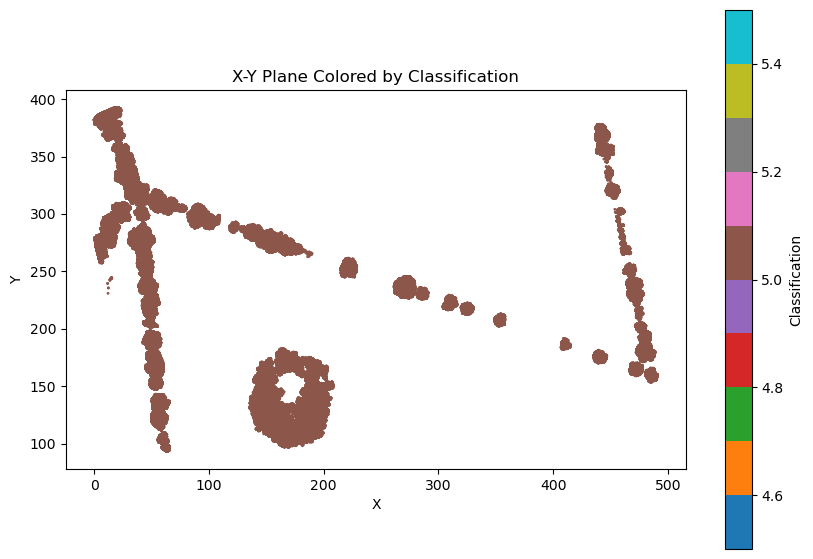

In [7]:
#XY plane plot
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(filtered_df['X'], filtered_df['Y'], 
                      s=1, c=filtered_df['Classification'], 
                      cmap='tab10',
                      marker='o')
plt.colorbar(scatter, label='Classification')
ax.set_title('X-Y Plane Colored by Classification')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_aspect('equal')
plt.show()


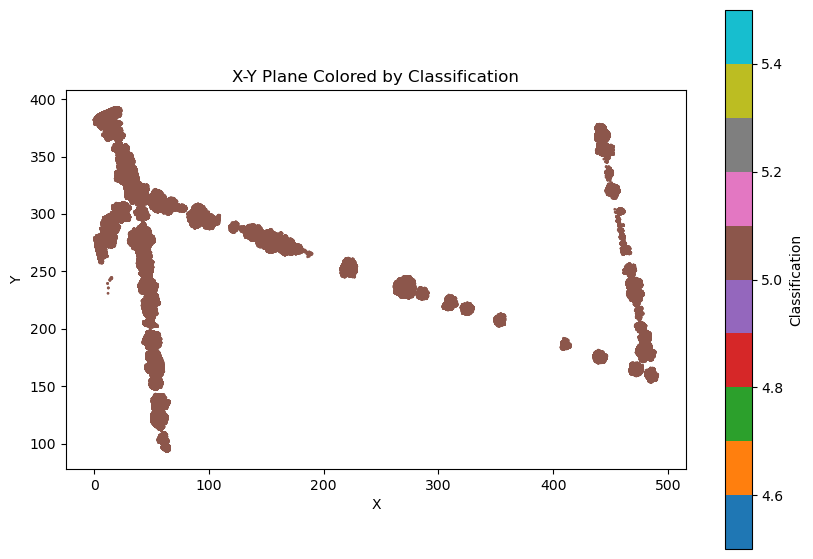

In [8]:
#remove area of circle
center_x, center_y = 170, 145
radius = 50
distance_from_center = np.sqrt((filtered_df['X'] - center_x)**2 + (filtered_df['Y'] - center_y)**2)
filtered_df = filtered_df[distance_from_center > radius]
filtered_df = filtered_df[filtered_df['X'] < 550]  # also remove points with X > 300 to focus on the area of interest

#XY plane plot
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(filtered_df['X'], filtered_df['Y'], 
                      s=1, c=filtered_df['Classification'], 
                      cmap='tab10',
                      marker='o')
plt.colorbar(scatter, label='Classification')
ax.set_title('X-Y Plane Colored by Classification')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_aspect('equal')
plt.show()

# Tree top detection and counting

In [9]:
def adaptive_radius(z, min_r=1.0, max_r=5.0):
    return np.clip(0.1 * z + 1.5, min_r, max_r)  # smaller windows = more tops detected

def find_treetops_fast(pointcloud_df, min_height=2.0, top_percentile=0.90):
    trees = pointcloud_df[pointcloud_df['Z'] > min_height].copy().reset_index(drop=True)
    
    # Only keep points in the top 10% of height
    z_threshold = trees['Z'].quantile(top_percentile)
    candidates = trees[trees['Z'] >= z_threshold].reset_index(drop=True)
    print(f"Reduced from {len(trees)} to {len(candidates)} candidate points")
    
    points_xy = candidates[['X', 'Y']].values
    points_z = candidates['Z'].values
    
    # Use lidR matching formula
    radii = adaptive_radius(points_z)
    
    bt = BallTree(points_xy)
    max_radius = radii.max()
    
    print("Querying BallTree...")
    all_neighbors = bt.query_radius(points_xy, r=max_radius)
    
    is_treetop = np.zeros(len(candidates), dtype=bool)
    for i, neighbors in enumerate(tqdm(all_neighbors, desc="Finding treetops")):
        dists = np.sqrt(((points_xy[neighbors] - points_xy[i]) ** 2).sum(axis=1))
        adaptive_neighbors = neighbors[dists <= radii[i]]
        if points_z[i] == points_z[adaptive_neighbors].max():
            is_treetop[i] = True
    
    return candidates[is_treetop].reset_index(drop=True)

def win_fun(z, slope=0.22, intercept=2.5):
    return slope * z + intercept # window radius grows linearly with height


def vwf(pointcloud_df, win_fun, min_height=8.0):
    candidates = (
        pointcloud_df[pointcloud_df['Z'] >= min_height]
        .copy()
        .reset_index(drop=True)
    )

    print(f"Candidates after min_height filter: {len(candidates)}")

    xy    = candidates[['X', 'Y']].values
    z     = candidates['Z'].values
    radii = np.vectorize(win_fun)(z) # compute adaptive search radius for every point

    bt = BallTree(xy)

    all_neighbors = bt.query_radius(xy, r=radii.max()) # query once at max radius, trim adaptively per point below

    is_treetop = np.zeros(len(candidates), dtype=bool)

    for i, neighbors in enumerate(tqdm(all_neighbors, desc="VWF")):
        dists  = np.linalg.norm(xy[neighbors] - xy[i], axis=1)
        within = neighbors[dists <= radii[i]] # trim to this point's own adaptive radius

        local_max_z   = z[within].max()
        local_max_idx = within[z[within] == local_max_z]

        # mark as treetop only if this point is the maximum and wins the tie-break
        if z[i] == local_max_z and i == local_max_idx.min():
            is_treetop[i] = True

    treetops = candidates[is_treetop].copy().reset_index(drop=True)
    treetops['winRadius'] = np.vectorize(win_fun)(treetops['Z'])
    return treetops

def cylinder(pointcloud_df, min_height=2.0, radius=2.0, batch_size=10000):
    candidates = (
        pointcloud_df[pointcloud_df['Z'] >= min_height]
        .copy()
        .reset_index(drop=True)
    ) # drop points below min_height before cylinder filtering

    xy = candidates[['X', 'Y']].values
    z  = candidates['Z'].values

    bt = BallTree(xy)
    is_unshadowed = np.ones(len(xy), dtype=bool)

    for start in tqdm(range(0, len(xy), batch_size), desc="Cylinder filter"):
        end      = min(start + batch_size, len(xy))
        batch_xy = xy[start:end]
        batch_z  = z[start:end]

        neighbors_list = bt.query_radius(batch_xy, r=radius) # fixed radius for all points

        for local_i, neighbors in enumerate(neighbors_list):
            i      = start + local_i
            z_diff = z[neighbors] - z[i] # positive means neighbour is taller

            # a point is shadowed if any taller neighbour exists within the cylinder radius
            if np.any(z_diff > 0):
                is_unshadowed[i] = False

    result = candidates[is_unshadowed].reset_index(drop=True)
    print(f"Cylinder filter: {len(candidates)} -> {len(result)} points")
    return result


cone_df = cylinder(filtered_df, min_height=8, radius=2.0)
treetops_df = vwf(cone_df, win_fun=win_fun, min_height=1.5)
#treetops_df = find_treetops_fast(filtered_df, min_height=1.5, top_percentile=0.5)
print(f"Identified {len(treetops_df)} treetops.")

Cylinder filter: 100%|██████████| 45/45 [00:08<00:00,  5.58it/s]


Cylinder filter: 447900 -> 193 points
Candidates after min_height filter: 193


VWF: 100%|██████████| 193/193 [00:00<00:00, 86586.87it/s]

Identified 86 treetops.


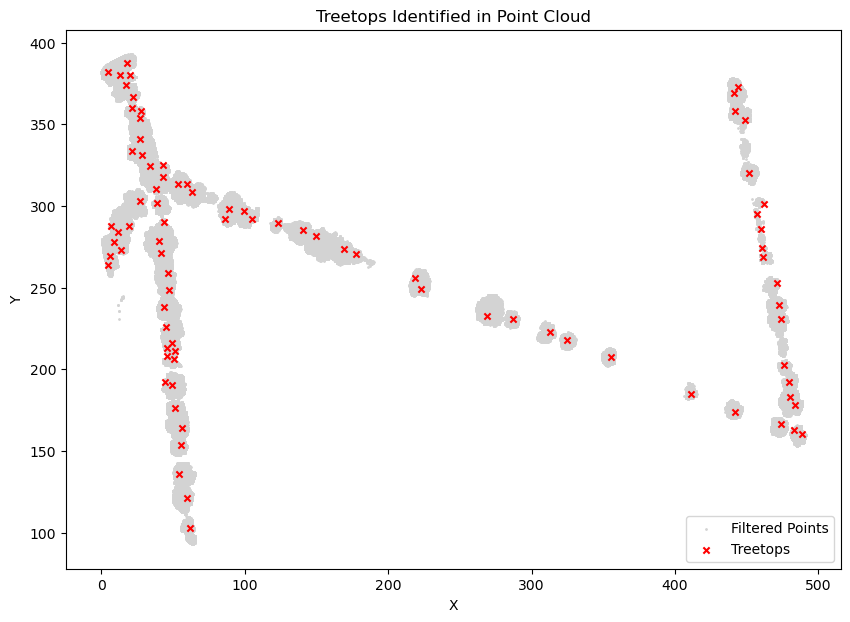

In [10]:
#fig1, ax1 = visualize_pointcloud(filtered_df, show_head=False)
#fig2, ax2 = visualize_pointcloud(treetops_df, show_head=False)

#combined plot
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(filtered_df['X'], filtered_df['Y'], s=1, c='lightgray', marker='o', label='Filtered Points')
ax.scatter(treetops_df['X'], treetops_df['Y'], s=20, c='red', marker='x', label='Treetops')
ax.set_title('Treetops Identified in Point Cloud')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend()

# Segmentation

Given the number of trees as input, do instance segmentation

In [15]:
method = 'watershed' # 'kmeans' or 'watershed'
tree_count_estimate = len(treetops_df)
use_guess_positions = True

def watershed_segmentation(pointcloud_df, treetops_df, id_field='treeID', batch_size=10000):
    xy       = pointcloud_df[['X', 'Y']].values
    seed_xy  = treetops_df[['X', 'Y']].values
    seed_ids = treetops_df[id_field].values

    bt = BallTree(seed_xy) # build tree on treetop positions

    tree_ids = np.empty(len(xy), dtype=seed_ids.dtype)

    for start in tqdm(range(0, len(xy), batch_size), desc="Watershed KNN assignment"):
        end        = min(start + batch_size, len(xy))
        batch_xy   = xy[start:end]
        _, indices = bt.query(batch_xy, k=1) # assign each point to nearest treetop
        tree_ids[start:end] = seed_ids[indices.ravel()]

    result = pointcloud_df.copy()
    result[id_field] = tree_ids
    return result

def segment_pointcloud(pointcloud_df, num_trees, method='kmeans', initial_positions=None):
    points_xy = pointcloud_df[['X', 'Y']].values
    
    if method == 'kmeans':
        if initial_positions is not None:
            kmeans = KMeans(n_clusters=num_trees, 
                            init=initial_positions,  # use treetop positions as initial centroids
                            n_init=1, # don't run multiple times if we provide initial positions, but do run multiple times if we don't to find better centroids
                            random_state=42)
        else:
            kmeans = KMeans(n_clusters=num_trees, 
                            n_init=1,
                            random_state=42)
        pointcloud_df['tree_id'] = kmeans.fit_predict(points_xy)
        return pointcloud_df
    
    if method == 'watershed':
        if treetops_df is None:
            raise ValueError("treetops_df must be provided when using watershed method")
        pointcloud_df = watershed_segmentation(pointcloud_df, treetops_df)

    return pointcloud_df
        

# Prepare initial positions from treetop detection
initial_positions = treetops_df[['X', 'Y']].values if use_guess_positions else None

time_start = time.time()

segmented_df = segment_pointcloud(filtered_df, 
                                   num_trees=tree_count_estimate, 
                                   method='kmeans',
                                   initial_positions=initial_positions)
time_end = time.time()
runtime = time_end - time_start

print('=== Segmentation Results ===')
print(f'Method:              {method}')
print(f'Number of trees:     {tree_count_estimate}')
print(f'Used treetop guess:  {use_guess_positions}')
print(f'Runtime:             {round(runtime, 2)} seconds')
#TODO: compare with ground truth when available

=== Segmentation Results ===
Method:              watershed
Number of trees:     86
Used treetop guess:  True
Runtime:             0.78 seconds


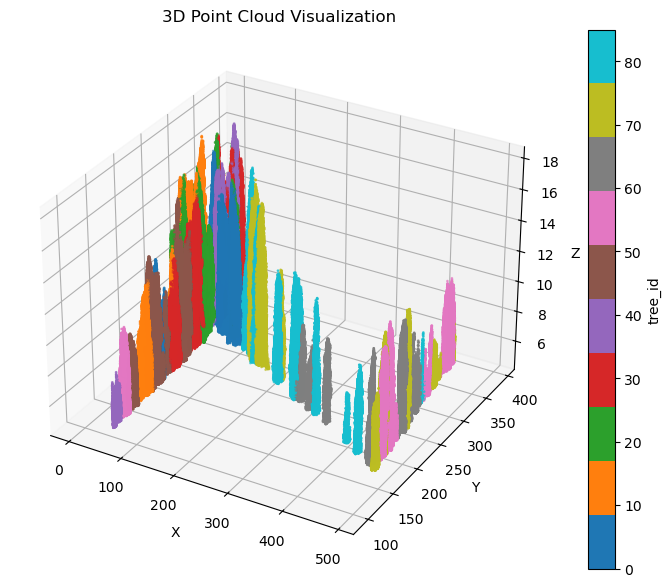


=== Tree Crown Statistics ===
         Crown Area (m²)  Max Circle Area (m²)  Max Circle Radius (m)  Point Count  height
Tree ID                                                                                   
0                  94.87                 50.89                   4.02        11588  10.773
1                 105.47                 65.60                   4.57         4542  10.773
2                  27.27                 19.16                   2.47         2420  10.773
3                  93.59                 53.85                   4.14         4908  10.773
4                  94.64                 66.76                   4.61         5709  10.773
5                 200.93                144.83                   6.79         9021  10.773
6                 106.76                 69.90                   4.72         5200  10.773
7                  89.16                 56.86                   4.25         8090  10.773
8                  87.54                 65.16             

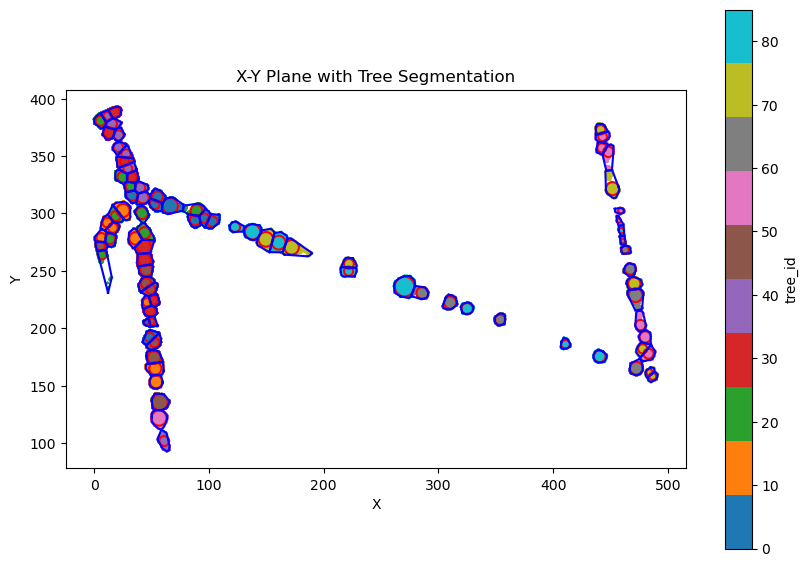

In [16]:
visualize_pointcloud(segmented_df, labels="tree_id", show_head=False)
trees_spec_df=X_Y_plane(segmented_df, area_calucation=True, height_caluation=True)


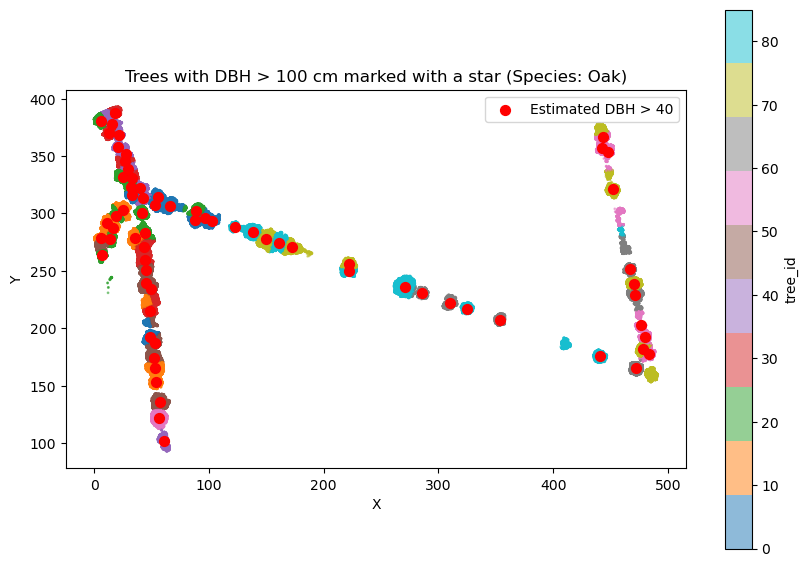

In [18]:
# Allometric coefficients for Diameter at Breast Height (DBH) estimation

species="Oak" #Change to your desired species

tree_species_coefficients = {
    "Alder": 21,
    "Ash": 19.5,
    "Birch": 18.1,
    "Oak": 19.7
}

def diameter_from_area(area):
    diameter = 2 * np.sqrt(area / np.pi)
    return diameter

def dbh_from_diameter(diameter):
    dbh = diameter * 100 / 24
    return dbh
# --- Add columns to previous results ---
tree_max_height = segmented_df.groupby('tree_id')['Z'].max()
trees_spec_df['Max Height (m)']  = tree_max_height.round(2)
trees_spec_df['Species']         = species
trees_spec_df['estimated_dbh'] = dbh_from_diameter(diameter_from_area(trees_spec_df["Crown Area (m²)"]))
trees_spec_df['Protected'] = diameter_from_area(trees_spec_df["Crown Area (m²)"]) > tree_species_coefficients[species] #DBH threshold calculated as in paper
#print(trees_spec_df.to_string())
trees_spec_df.to_csv('tree_metrics.csv', index=True)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(segmented_df['X'], segmented_df['Y'],
                     s=1, c=segmented_df['tree_id'],
                     cmap='tab10', marker='o', alpha=0.5)
plt.colorbar(scatter, label='tree_id')

# Overlay trees above threshold
for tree_id, row in trees_spec_df[trees_spec_df['Protected']].iterrows():
    group = segmented_df[segmented_df['tree_id'] == tree_id]
    center_x = group['X'].mean()
    center_y = group['Y'].mean()
    ax.scatter(center_x, center_y,
               s=100, c='red', marker='*', zorder=5,
               label='Protected' if tree_id == trees_spec_df[trees_spec_df['Protected']].index[0] else "")

for tree_id, row in trees_spec_df[trees_spec_df['estimated_dbh'] > 40].iterrows():
    group = segmented_df[segmented_df['tree_id'] == tree_id]
    center_x = group['X'].mean()
    center_y = group['Y'].mean()

    ax.scatter(center_x, center_y,
               s=50, c='red', marker='o', zorder=5,
               label='Estimated DBH > 40' if tree_id == trees_spec_df[trees_spec_df['estimated_dbh'] > 40].index[0] else "")
ax.legend()
ax.set_title(f'Trees with DBH > 100 cm marked with a star (Species: {species})')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_aspect('equal')
plt.show()